In [ ]:
import random
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime
import os

fake = Faker("es_ES")

# -----------------------------
# CONFIG
# -----------------------------
N = 5000

etnias = ["latino", "afrodescendiente", "blanco", "asiatico", "indio", "griego"]
generos = ["varon", "mujer", "otros"]

inicio_empresa = datetime(1980, 11, 23)
fin_datos = datetime(2025, 3, 1)

# -----------------------------
# PUESTOS
# -----------------------------
roles_por_departamento = {
    "Ventas": ["Ejecutivo","Representante","Gerente","Analista","BizDev"],
    "Marketing": ["Marketing","Analista MKT","Manager MKT","Content","SEO"],
    "IT": ["Dev","Data","Sysadmin","Soporte","Arquitecto"],
    "RRHH": ["HR Analyst","Recruiter","HRBP","Training","HR Manager"],
    "Finanzas": ["Analista","Contador","Controller","Tesorería","Finanzas Manager"]
}

seniority_levels = ["JR", "MID", "SR", "LEAD"]

puestos_list = []
id_counter = 1

for depto, roles in roles_por_departamento.items():
    for rol in roles:
        for sen in seniority_levels:
            puestos_list.append((id_counter, rol, depto, sen))
            id_counter += 1

df_puestos = pd.DataFrame(puestos_list, columns=[
    "id_puesto", "rol", "departamento", "seniority"
])

puestos_dict = df_puestos.set_index("id_puesto").to_dict("index")

# -----------------------------
# EMPLEADOS
# -----------------------------
ids = np.arange(1, N+1)

def genero_por_depto(depto):
    if depto in ["RRHH", "Marketing"]:
        return np.random.choice(["mujer","varon"], p=[0.7,0.3])
    elif depto == "Finanzas":
        return np.random.choice(["varon","mujer"], p=[0.7,0.3])
    else:
        return np.random.choice(generos)

puestos_iniciales = np.random.choice(df_puestos["id_puesto"], N)

genero_col = [genero_por_depto(puestos_dict[p]["departamento"]) for p in puestos_iniciales]
etnia_col = np.random.choice(etnias, N)
edad_col = np.random.randint(18, 70, N)

start_days = np.random.randint(0, (fin_datos - inicio_empresa).days, N)
fecha_inicio = pd.to_datetime([inicio_empresa + pd.Timedelta(days=int(x)) for x in start_days])

discapacidad = np.array([
    1 if (f.year >= 2006 and random.random() < 0.02) else 0
    for f in fecha_inicio
])

nombres = [f"{fake.last_name()}, {fake.first_name()}" for _ in range(N)]

df_empleados = pd.DataFrame({
    "id_empleado": ids,
    "nombre_completo": nombres,
    "fecha_inicio": fecha_inicio,
    "genero": genero_col,
    "edad": edad_col,
    "discapacidad": discapacidad,
    "etnia": etnia_col
})

# -----------------------------
# SALARIOS + HISTORIAL
# -----------------------------
sueldo_map = {"JR": 1000, "MID": 3000, "SR": 8000, "LEAD": 15000}
next_map = {"JR": "MID", "MID": "SR", "SR": "LEAD", "LEAD": "LEAD"}

salarios = []
historial_puestos = {}

for emp, puesto_ini in zip(df_empleados.to_dict("records"), puestos_iniciales):

    meses = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="MS")
    puesto_actual = puesto_ini

    historial_puestos[emp["id_empleado"]] = {}

    for i, m in enumerate(meses):

        current = puestos_dict[puesto_actual]

        if i % 36 == 0 and i != 0:
            next_sen = next_map[current["seniority"]]

            prob = 0.3
            if next_sen == "LEAD":
                if m.year < 2010:
                    if emp["genero"] == "varon" and emp["etnia"] == "blanco":
                        prob = 0.8
                    else:
                        prob = 0.05
                else:
                    if emp["genero"] == "varon":
                        prob = 0.6
                    else:
                        prob = 0.2

            if random.random() < prob:
                for k, v in puestos_dict.items():
                    if v["rol"] == current["rol"] and v["departamento"] == current["departamento"] and v["seniority"] == next_sen:
                        puesto_actual = k
                        break

        puesto_info = puestos_dict[puesto_actual]
        sueldo = sueldo_map[puesto_info["seniority"]]

        if emp["genero"] == "mujer":
            sueldo *= 0.85 if m.year < 2010 else 0.95

        if puesto_info["departamento"] == "Finanzas":
            sueldo *= 1.2

        salarios.append((emp["id_empleado"], puesto_actual, round(sueldo,2), m))
        historial_puestos[emp["id_empleado"]][m] = puesto_actual

df_salarios = pd.DataFrame(salarios, columns=["id_empleado","id_puesto","sueldo","mes"])

# -----------------------------
# ENCUESTAS
# -----------------------------
encuestas = []

for emp in df_empleados.to_dict("records"):

    fechas = pd.date_range(start=emp["fecha_inicio"], end=fin_datos, freq="12MS")

    for f in fechas:

        historial = historial_puestos[emp["id_empleado"]]
        fechas_hist = [d for d in historial.keys() if d <= f]

        if len(fechas_hist) == 0:
            continue

        fecha_ref = max(fechas_hist)
        puesto_actual = historial[fecha_ref]
        puesto = puestos_dict[puesto_actual]

        base_sat = 4 if emp["etnia"] == "blanco" else 3
        wlb = 2 if puesto["seniority"] == "JR" else 4

        equidad = 4
        if emp["discapacidad"] == 1:
            equidad = 2 + (f.year - 2006) * 0.05
        if emp["etnia"] == "indio":
            equidad -= 1

        encuestas.append((
            emp["id_empleado"],
            f,
            int(np.clip(base_sat + random.randint(-1,1),1,5)),
            random.randint(2,5),
            int(np.clip(wlb + random.randint(-1,1),1,5)),
            int(np.clip(equidad,1,5))
        ))

df_encuestas = pd.DataFrame(encuestas, columns=[
    "id_empleado","date","score_satisfacion","score_inclusion","work_life_balance","percepcion_equidad"
])

# -----------------------------
# ATTRITION
# -----------------------------
ult = df_encuestas.sort_values("date").groupby("id_empleado").last()

prob_attr = (
    (5 - ult["score_satisfacion"]) * 0.15 +
    (5 - ult["work_life_balance"]) * 0.1 +
    (5 - ult["percepcion_equidad"]) * 0.2
)

prob_attr = prob_attr.reindex(df_empleados["id_empleado"]).values

df_empleados["attrition"] = (np.random.rand(N) < prob_attr).astype(int)

mask = df_empleados["attrition"] == 1
deltas = np.random.randint(200, 2000, N)

df_empleados["fecha_renuncia"] = pd.NaT
df_empleados.loc[mask, "fecha_renuncia"] = (
    df_empleados.loc[mask, "fecha_inicio"] +
    pd.to_timedelta(deltas[mask], unit="D")
)



output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\Tabla correcion\Etl"
os.makedirs(output_path, exist_ok=True)

# EMPLEADOS
duplicados = df_empleados.sample(4, random_state=1).copy()
df_empleados = pd.concat([df_empleados, duplicados], ignore_index=True)

idx_nulos = np.random.choice(df_empleados.index, 2, replace=False)
df_empleados.loc[idx_nulos, "nombre_completo"] = np.nan

idx_outliers = np.random.choice(df_empleados.index, 2, replace=False)
df_empleados.loc[idx_outliers[0], "edad"] = 125
df_empleados.loc[idx_outliers[1], "edad"] = 320

idx_futuro = np.random.choice(df_empleados.index, 2, replace=False)
df_empleados.loc[idx_futuro, "fecha_renuncia"] = pd.to_datetime("2028-06-01")

# SALARIOS
idx_fake_puesto = np.random.choice(df_salarios.index, 5, replace=False)
df_salarios.loc[idx_fake_puesto, "id_puesto"] = np.random.randint(101,150,5)

for _ in range(10):
    idx = np.random.randint(1, len(df_salarios))
    df_salarios.loc[idx, "sueldo"] = df_salarios.loc[idx, "sueldo"] * 10

# ENCUESTAS
idx_nan = np.random.choice(df_encuestas.index, 5, replace=False)
df_encuestas.loc[idx_nan, [
    "score_satisfacion",
    "score_inclusion",
    "work_life_balance",
    "percepcion_equidad"
]] = np.nan

idx_outliers_enc = np.random.choice(df_encuestas.index, 5, replace=False)
df_encuestas.loc[idx_outliers_enc, "score_satisfacion"] = 50
df_encuestas.loc[idx_outliers_enc, "work_life_balance"] = 40

# EXPORT FINAL
df_empleados.to_csv(os.path.join(output_path, "empleados_corruptos.csv"), index=False)
df_puestos.to_csv(os.path.join(output_path, "puestos_corruptos.csv"), index=False)
df_salarios.to_csv(os.path.join(output_path, "salarios_corruptos.csv"), index=False)
df_encuestas.to_csv(os.path.join(output_path, "encuestas_corruptos.csv"), index=False)

print("⚠️ Dataset con errores generado para ETL")

⚠️ Dataset con errores generado para ETL


In [3]:
# Proceso de ETL. Detección de duplicados 

# Total de registros
total_registros = len(df_empleados)

# IDs únicos
ids_unicos = df_empleados["id_empleado"].nunique()

print(f"Total registros: {total_registros}")
print(f"IDs únicos: {ids_unicos}")

# Diferencia (cantidad de duplicados)
duplicados = total_registros - ids_unicos
print(f"Cantidad de IDs duplicados: {duplicados}")

# -----------------------------
# DETECTAR FILAS DUPLICADAS
# -----------------------------

# Filas con IDs repetidos (todas, no solo una)
df_duplicados = df_empleados[df_empleados.duplicated(subset="id_empleado", keep=False)]

# Ordenar para mejor lectura
df_duplicados = df_duplicados.sort_values(by="id_empleado")

# Mostrar resultado
if df_duplicados.empty:
    print("✅ No hay IDs duplicados")
else:
    print("⚠️ IDs duplicados encontrados:")
    print(df_duplicados)

Total registros: 5004
IDs únicos: 5000
Cantidad de IDs duplicados: 4
⚠️ IDs duplicados encontrados:
      id_empleado     nombre_completo fecha_inicio genero  edad  discapacidad  \
2764         2765      Gabaldón, Nilo   1988-09-29  varon    29             0   
5000         2765      Gabaldón, Nilo   1988-09-29  varon    29             0   
5003         3500    Chamorro, Carlos   2014-02-18  mujer    44             0   
3499         3500    Chamorro, Carlos   2014-02-18  mujer    44             0   
5002         3815  Lopez, María Belén   1983-08-23  mujer    56             0   
3814         3815  Lopez, María Belén   1983-08-23  mujer    56             0   
4767         4768  Cifuentes, Arsenio   1993-11-20  varon    63             0   
5001         4768  Cifuentes, Arsenio   1993-11-20  varon    63             0   

         etnia  attrition fecha_renuncia  
2764  asiatico          1     1993-06-13  
5000  asiatico          1     1993-06-13  
5003    griego          1     2019-01-15 

In [ ]:
#Eliminaremos uno de los dos registros duplicados de la tabla anterior
df_empleados = df_empleados.sort_values(by="fecha_inicio", ascending=False)\
                           .drop_duplicates(subset="id_empleado", keep="last")

In [ ]:
#Vemos que ahora cada empleado de la empresa tiene un id que le corresponde solo a él y no esta duplicado
# Total de registros
total_registros = len(df_empleados)

# Cantidad de IDs únicos
ids_unicos = df_empleados["id_empleado"].nunique()

print(f"Total registros: {total_registros}")
print(f"IDs únicos: {ids_unicos}")
print(f"Diferencia (duplicados): {total_registros - ids_unicos}")

Total registros: 5000
IDs únicos: 5000
Diferencia (duplicados): 0


In [6]:
#Registros faltantes
na_tabla = pd.DataFrame({
    "columna": df_empleados.columns,
    "nulos": df_empleados.isna().sum().values,
    "porcentaje_nulos": (df_empleados.isna().mean().values * 100).round(2)
})

print(na_tabla)

           columna  nulos  porcentaje_nulos
0      id_empleado      0              0.00
1  nombre_completo      2              0.04
2     fecha_inicio      0              0.00
3           genero      0              0.00
4             edad      0              0.00
5     discapacidad      0              0.00
6            etnia      0              0.00
7        attrition      0              0.00
8   fecha_renuncia   1870             37.40


In [ ]:
#Vemos que hay dos registros nulos en la tabla nombre_completo. Los eliminamos. Los registros nulos de fecha_renuncia significan que nuestro empleado sigue en la empresa. Los dejamos tal cual están
# Eliminar registros con NA en nombre_completo
df_empleados = df_empleados.dropna(subset=["nombre_completo"])

print("✅ Registros con nombre_completo nulo eliminados")

✅ Registros con nombre_completo nulo eliminados


In [8]:
# Revisando las edades 
# Conteo de registros por edad
tabla_edades = df_empleados["edad"].value_counts().reset_index()

# Renombrar columnas
tabla_edades.columns = ["edad", "cantidad"]

# Ordenar por edad (ascendente)
tabla_edades = tabla_edades.sort_values(by="edad")

print(tabla_edades)

    edad  cantidad
32    18        93
15    19       102
6     20       107
9     21       105
22    22        99
16    23       102
45    24        85
4     25       109
26    26        96
5     27       108
8     28       107
31    29        94
49    30        79
24    31        97
51    32        77
7     33       107
33    34        93
35    35        91
34    36        91
50    37        77
47    38        83
12    39       104
39    40        89
27    41        95
14    42       103
23    43        98
28    44        95
36    45        90
3     46       110
40    47        88
11    48       104
1     49       112
20    50       100
37    51        90
13    52       103
41    53        87
10    54       105
0     55       113
42    56        86
25    57        96
38    58        89
43    59        85
46    60        84
19    61       101
2     62       110
29    63        95
44    64        85
18    65       101
17    66       101
21    67        99
48    68        82
30    69    

In [9]:
# Eliminamos los Outliers
# Eliminar registros con edades outliers específicas
df_empleados = df_empleados[~df_empleados["edad"].isin([125, 320])]

print("✅ Registros con edad 125 y 320 eliminados")

✅ Registros con edad 125 y 320 eliminados


In [ ]:
#Outliers de fechas, todas aquellos mayores al tope de nuestro dataset(fecha del ultimo pago)
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 1. Fecha máxima en salarios
fecha_max_salarios = df_salarios["mes"].max()
print(f"Fecha máxima en salarios: {fecha_max_salarios}")

# 2. Detectar errores
errores_fecha = df_empleados[
    df_empleados["fecha_renuncia"] > fecha_max_salarios
]

# 3. Mostrar resultado completo
if errores_fecha.empty:
    print("✅ No hay fechas de renuncia fuera de rango")
else:
    print("⚠️ Registros con fecha de renuncia inválida:")
    print(errores_fecha.to_string(index=False))

Fecha máxima en salarios: 2025-03-01 00:00:00
⚠️ Registros con fecha de renuncia inválida:
 id_empleado         nombre_completo fecha_inicio genero  edad  discapacidad            etnia  attrition fecha_renuncia
         805         Rubio, Cristian   2025-02-26  mujer    49             0           latino          1     2026-09-02
        1862            Miró, Begoña   2025-02-15  varon    56             0           griego          1     2026-08-04
        3549        Cortes, Herminio   2025-02-15  otros    55             0           griego          1     2030-01-05
        1004          Rodrigo, Nydia   2025-02-12  varon    33             0         asiatico          1     2027-01-11
        3300       Céspedes, Aurelia   2025-02-11  mujer    53             0            indio          1     2027-07-01
         381       Herranz, Gregorio   2025-02-03  otros    27             0            indio          1     2029-03-05
        3893          Solsona, Juana   2025-01-31  otros    31       

In [12]:
# Eliminar registros con fecha_renuncia mayor al máximo de salarios
df_empleados = df_empleados[
    (df_empleados["fecha_renuncia"].isna()) |
    (df_empleados["fecha_renuncia"] <= df_salarios["mes"].max())
]

print("✅ Registros con fecha_renuncia inválida eliminados")

✅ Registros con fecha_renuncia inválida eliminados


In [ ]:
# Revisando la tabla salarios vemos que no hay ningun nulo 
na_salarios = pd.DataFrame({
    "columna": df_salarios.columns,
    "nulos": df_salarios.isna().sum().values,
    "porcentaje_nulos": (df_salarios.isna().mean().values * 100).round(2)
})

# Ordenar de mayor a menor
na_salarios = na_salarios.sort_values(by="nulos", ascending=False)

print(na_salarios)

       columna  nulos  porcentaje_nulos
0  id_empleado      0               0.0
1    id_puesto      0               0.0
2       sueldo      0               0.0
3          mes      0               0.0


In [ ]:
#Si hay algun id_puesto que no esté entre 1 y 100 son registros inválidos que no existen en la tabla puestos. Los eliminamos 
df_puestos_invalidos = df_salarios[
    (df_salarios["id_puesto"] < 1) | (df_salarios["id_puesto"] > 100)
]

print(df_puestos_invalidos)

         id_empleado  id_puesto   sueldo        mes
328154          1227        110  12750.0 1993-12-01
787125          2961        113  14250.0 2017-11-01
803238          3027        131   3000.0 2019-05-01
970053          3673        105   2550.0 2002-12-01
1303884         4946        101   9600.0 1993-08-01


In [15]:
df_salarios = df_salarios[
    df_salarios["id_puesto"].between(1, 100)
]

print("✅ Registros con id_puesto inválido eliminados")

✅ Registros con id_puesto inválido eliminados


<Figure size 1000x600 with 0 Axes>

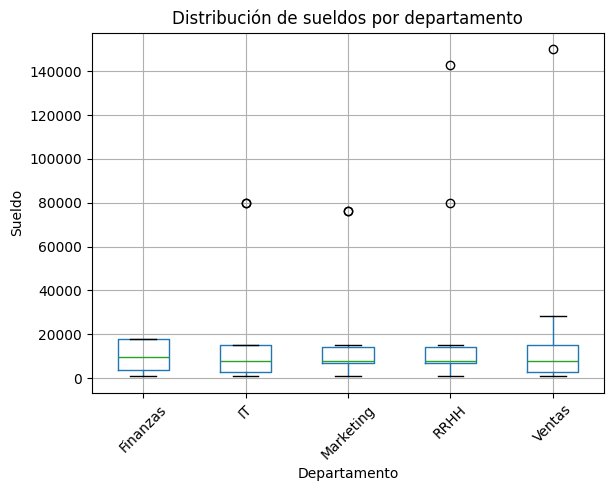

In [ ]:
#Outliers en tabla sueldo. Comenzamos con diagramas de tipo boxplot para ver si hay outliers.
import matplotlib.pyplot as plt

# Unir salarios con puestos para traer departamento
df_plot = df_salarios.merge(df_puestos, on="id_puesto", how="left")

# Boxplot
plt.figure(figsize=(10,6))
df_plot.boxplot(column="sueldo", by="departamento")

plt.title("Distribución de sueldos por departamento")
plt.suptitle("")  # limpia título automático
plt.xlabel("Departamento")
plt.ylabel("Sueldo")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Unir salarios con puestos para traer rol y departamento.Comparamos con una medida de tendencia central no sensible a valores extremos: la mediana
df_stats = df_salarios.merge(df_puestos, on="id_puesto", how="left")

# Agrupar y calcular métricas
resultado = df_stats.groupby(["rol", "departamento"])["sueldo"].agg(
    mediana="median",
    maximo="max"
).reset_index()

print(resultado)

                 rol departamento  mediana    maximo
0           Analista     Finanzas  15300.0   18000.0
1           Analista       Ventas   8000.0   15000.0
2       Analista MKT    Marketing   8000.0   76000.0
3         Arquitecto           IT   8000.0   15000.0
4             BizDev       Ventas   8000.0   28500.0
5           Contador     Finanzas   9600.0   18000.0
6            Content    Marketing   7600.0   15000.0
7         Controller     Finanzas   9600.0   18000.0
8               Data           IT   8000.0   15000.0
9                Dev           IT   8000.0   80000.0
10         Ejecutivo       Ventas   8000.0   15000.0
11  Finanzas Manager     Finanzas   9600.0   18000.0
12           Gerente       Ventas   8000.0  150000.0
13        HR Analyst         RRHH   8000.0   15000.0
14        HR Manager         RRHH   8000.0   15000.0
15              HRBP         RRHH   8000.0  142500.0
16       Manager MKT    Marketing   7600.0   76000.0
17         Marketing    Marketing   8000.0   1

In [18]:
# Filtrar donde el máximo es al menos 10 veces la mediana
outliers_grupos = resultado[
    resultado["maximo"] >= resultado["mediana"] * 10
]

print(outliers_grupos)

            rol departamento  mediana    maximo
9           Dev           IT   8000.0   80000.0
12      Gerente       Ventas   8000.0  150000.0
15         HRBP         RRHH   8000.0  142500.0
16  Manager MKT    Marketing   7600.0   76000.0


In [ ]:
#Buscamos saltos de salarios que nos resulten llamativos
# 1. Ordenar correctamente
df_salarios = df_salarios.sort_values(by=["id_empleado", "mes"])

# 2. Calcular métricas temporales
df_salarios["sueldo_anterior"] = df_salarios.groupby("id_empleado")["sueldo"].shift(1)
df_salarios["mes_anterior"] = df_salarios.groupby("id_empleado")["mes"].shift(1)

# 3. Calcular variación porcentual
df_salarios["variacion"] = (
    (df_salarios["sueldo"] - df_salarios["sueldo_anterior"]) 
    / df_salarios["sueldo_anterior"]
)

# 4. Filtrar saltos mayores al 50%
saltos = df_salarios[df_salarios["variacion"] > 0.5].copy()

# 5. Armar dataset en pares (antes vs después)
resultado_pares = saltos[[
    "id_empleado",
    "mes_anterior",
    "sueldo_anterior",
    "mes",
    "sueldo",
    "variacion"
]]

print(resultado_pares)

         id_empleado mes_anterior  sueldo_anterior        mes   sueldo  \
324                1   2012-03-01           8000.0 2012-04-01  15000.0   
516                2   2007-02-01           1000.0 2007-03-01   3000.0   
588                2   2013-02-01           3000.0 2013-03-01   8000.0   
660                2   2019-02-01           8000.0 2019-03-01  15000.0   
1051               5   2017-11-01           7600.0 2017-12-01  14250.0   
...              ...          ...              ...        ...      ...   
1317902         4998   1995-01-01           1200.0 1995-02-01   3600.0   
1318010         4998   2004-01-01           3600.0 2004-02-01   9600.0   
1318046         4998   2007-01-01           9600.0 2007-02-01  18000.0   
1318523         5000   2006-05-01           3000.0 2006-06-01   8000.0   
1318595         5000   2012-05-01           8000.0 2012-06-01  15000.0   

         variacion  
324       0.875000  
516       2.000000  
588       1.666667  
660       0.875000  
1051  

In [ ]:
#Hacemos lo mismo pero ahora no contemplamos cambios de puestos laborales (sino el mismo puesto un mes antes)
#Empieza a ser claro donde están los outliers
# 1. Ordenar
df_salarios = df_salarios.sort_values(by=["id_empleado", "mes"])

# 2. Traer valores anteriores
df_salarios["sueldo_anterior"] = df_salarios.groupby("id_empleado")["sueldo"].shift(1)
df_salarios["mes_anterior"] = df_salarios.groupby("id_empleado")["mes"].shift(1)
df_salarios["puesto_anterior"] = df_salarios.groupby("id_empleado")["id_puesto"].shift(1)

# 3. Calcular variación SOLO si el puesto es el mismo
df_salarios["variacion"] = np.where(
    df_salarios["id_puesto"] == df_salarios["puesto_anterior"],
    (df_salarios["sueldo"] - df_salarios["sueldo_anterior"]) / df_salarios["sueldo_anterior"],
    np.nan
)

# 4. Filtrar saltos > 50%
saltos = df_salarios[df_salarios["variacion"] > 0.5].copy()

# 5. Dataset final en pares
resultado_pares = saltos[[
    "id_empleado",
    "id_puesto",
    "mes_anterior",
    "sueldo_anterior",
    "mes",
    "sueldo",
    "variacion"
]]

print(resultado_pares)

        id_empleado  id_puesto mes_anterior  sueldo_anterior        mes  \
118952          436         27   2017-01-01           7600.0 2017-02-01   
137832          511         43   2018-03-01           8000.0 2018-04-01   
137864          511         43   2020-11-01           8000.0 2020-12-01   
290024         1084         12   2022-03-01          15000.0 2022-04-01   
298133         1112         31   2014-12-01           7600.0 2015-01-01   
364047         1368         72   2016-08-01          14250.0 2016-09-01   
483526         1825         49   2022-12-01           1000.0 2023-01-01   
693169         2612         13   1985-12-01           1000.0 1986-01-01   
834712         3140         71   2015-10-01           8000.0 2015-11-01   
903635         3415         18   2017-02-01           2850.0 2017-03-01   

          sueldo  variacion  
118952   76000.0        9.0  
137832   80000.0        9.0  
137864   80000.0        9.0  
290024  150000.0        9.0  
298133   76000.0        

In [21]:
# Eliminar registros extremos del dataset original
df_salarios = df_salarios.drop(index=resultado_pares.index)

print("✅ Outliers eliminados")

✅ Outliers eliminados


<Figure size 1000x600 with 0 Axes>

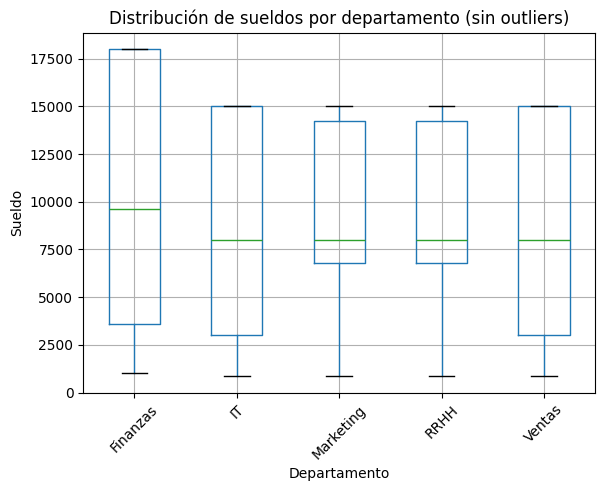

In [ ]:
#Los boxplot ya no presentan outliers
import matplotlib.pyplot as plt

# Merge con puestos
df_plot = df_salarios.merge(df_puestos, on="id_puesto", how="left")

# Boxplot limpio
plt.figure(figsize=(10,6))
df_plot.boxplot(column="sueldo", by="departamento")

plt.title("Distribución de sueldos por departamento (sin outliers)")
plt.suptitle("")
plt.xlabel("Departamento")
plt.ylabel("Sueldo")

plt.xticks(rotation=45)
plt.show()

In [23]:
#Veamos la tabla encuestas. En búsqueda de valores na
na_encuestas = pd.DataFrame({
    "columna": df_encuestas.columns,
    "nulos": df_encuestas.isna().sum().values,
    "porcentaje_nulos": (df_encuestas.isna().mean().values * 100).round(2)
})

print(na_encuestas.sort_values(by="nulos", ascending=False))

              columna  nulos  porcentaje_nulos
3     score_inclusion      5               0.0
2   score_satisfacion      5               0.0
4   work_life_balance      5               0.0
5  percepcion_equidad      5               0.0
1                date      0               0.0
0         id_empleado      0               0.0


In [24]:
registros_nulos = df_encuestas[df_encuestas.isna().any(axis=1)]

print(registros_nulos)

        id_empleado       date  score_satisfacion  score_inclusion  \
3466            158 2016-10-01                NaN              NaN   
38775          1712 2021-08-01                NaN              NaN   
46542          2051 1998-08-01                NaN              NaN   
88899          3964 2024-08-01                NaN              NaN   
105490         4711 2014-07-01                NaN              NaN   

        work_life_balance  percepcion_equidad  
3466                  NaN                 NaN  
38775                 NaN                 NaN  
46542                 NaN                 NaN  
88899                 NaN                 NaN  
105490                NaN                 NaN  


In [25]:
df_encuestas = df_encuestas.dropna()

print("✅ Registros con valores nulos eliminados")

✅ Registros con valores nulos eliminados


In [26]:
# Columnas de encuesta
columnas_scores = [
    "score_satisfacion",
    "score_inclusion",
    "work_life_balance",
    "percepcion_equidad"
]

# -----------------------------
# 1. Tabla de frecuencias
# -----------------------------
print("📊 DISTRIBUCIÓN DE VALORES (esperado 1 a 5)\n")

for col in columnas_scores:
    print(f"\n--- {col} ---")
    print(df_encuestas[col].value_counts().sort_index())

# -----------------------------
# 2. Detectar outliers (fuera de rango 1-5)
# -----------------------------
mask_outliers = (
    (df_encuestas[columnas_scores] < 1) |
    (df_encuestas[columnas_scores] > 5)
).any(axis=1)

df_outliers = df_encuestas[mask_outliers]

# -----------------------------
# 3. Mostrar resultados
# -----------------------------
print("\n⚠️ REGISTROS FUERA DE RANGO (≠ 1 a 5):")
print(df_outliers)

# -----------------------------
# 4. Mostrar completo (opcional)
# -----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n🔎 DETALLE COMPLETO:")
print(df_outliers.to_string(index=False))

# -----------------------------
# 5. Cantidad de outliers
# -----------------------------
print("\n📌 Cantidad de registros fuera de rango:", len(df_outliers))

📊 DISTRIBUCIÓN DE VALORES (esperado 1 a 5)


--- score_satisfacion ---
score_satisfacion
2.0     31140
3.0     37467
4.0     37396
5.0      6188
50.0        5
Name: count, dtype: int64

--- score_inclusion ---
score_inclusion
2.0    28096
3.0    28080
4.0    28243
5.0    27777
Name: count, dtype: int64

--- work_life_balance ---
work_life_balance
1.0      3435
2.0      3472
3.0     37418
4.0     34001
5.0     33865
40.0        5
Name: count, dtype: int64

--- percepcion_equidad ---
percepcion_equidad
1.0       71
2.0      343
3.0    18035
4.0    93747
Name: count, dtype: int64

⚠️ REGISTROS FUERA DE RANGO (≠ 1 a 5):
       id_empleado       date  score_satisfacion  score_inclusion  \
14070          632 2008-10-01               50.0              4.0   
38218         1687 2022-12-01               50.0              5.0   
38396         1697 1988-03-01               50.0              2.0   
63703         2819 2006-09-01               50.0              5.0   
78919         3514 2004-08-01  

In [ ]:
#Volvemos a cargar el data set y eliminamos los registros con na y con valores mayores a 5
import pandas as pd

# -----------------------------
# 1. Cargar CSV
# -----------------------------
ruta_csv = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\Tabla correcion\Etl\encuestas_corruptos.csv"
df_encuestas = pd.read_csv(ruta_csv)

# -----------------------------
# 2. Columnas a limpiar
# -----------------------------
columnas_scores = [
    "score_satisfacion",   # revisá si es "score_satisfaccion"
    "score_inclusion",
    "work_life_balance",
    "percepcion_equidad"
]

# Verificar columnas existentes
columnas_existentes = [col for col in columnas_scores if col in df_encuestas.columns]
columnas_faltantes = [col for col in columnas_scores if col not in df_encuestas.columns]

if columnas_faltantes:
    print(f"⚠️ Las siguientes columnas NO existen y serán ignoradas: {columnas_faltantes}")

if not columnas_existentes:
    raise ValueError("❌ Ninguna columna válida encontrada. Revisa los nombres.")

# -----------------------------
# 3. Eliminar filas con NA
# -----------------------------
df_encuestas = df_encuestas.dropna(subset=columnas_existentes)

# -----------------------------
# 4. Eliminar filas con valores > 5
# -----------------------------
df_encuestas_limpio = df_encuestas[df_encuestas[columnas_existentes].le(5).all(axis=1)].copy()

# -----------------------------
# 5. Resultados
# -----------------------------
print("📌 Registros después de limpiar NA y valores > 5:", len(df_encuestas_limpio))
print("\n🔎 Primeros registros:")
print(df_encuestas_limpio.head())

📌 Registros después de limpiar NA y valores > 5: 112191

🔎 Primeros registros:
   id_empleado        date  score_satisfacion  score_inclusion  \
0            1  1985-04-01                2.0              3.0   
1            1  1986-04-01                3.0              2.0   
2            1  1987-04-01                3.0              2.0   
3            1  1988-04-01                4.0              2.0   
4            1  1989-04-01                3.0              4.0   

   work_life_balance  percepcion_equidad  
0                5.0                 3.0  
1                4.0                 3.0  
2                4.0                 3.0  
3                5.0                 3.0  
4                5.0                 3.0  


In [ ]:
import pandas as pd
import numpy as np
import os

# -----------------------------
# PATHS
# -----------------------------
empleados_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\empleados.csv"
salarios_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\salarios.csv"
encuestas_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\csv2.0\encuestas_filtrado.csv"

output_path = r"C:\Users\lucas\OneDrive\Escritorio\No country dataset\Tabla correcion"
os.makedirs(output_path, exist_ok=True)

# -----------------------------
# CARGA
# -----------------------------
df_emp = pd.read_csv(empleados_path)
df_sal = pd.read_csv(salarios_path)
df_enc = pd.read_csv(encuestas_path)

# -----------------------------
# TIPOS
# -----------------------------
df_emp["fecha_inicio"] = pd.to_datetime(df_emp["fecha_inicio"], errors="coerce")
df_emp["fecha_renuncia"] = pd.to_datetime(df_emp["fecha_renuncia"], errors="coerce")
df_sal["mes"] = pd.to_datetime(df_sal["mes"], errors="coerce")
df_enc["date"] = pd.to_datetime(df_enc["date"], errors="coerce")

df_emp = df_emp.dropna(subset=["fecha_inicio"])
df_sal = df_sal.dropna(subset=["mes"])
df_enc = df_enc.dropna(subset=["date"])

# -----------------------------
# FECHA FIN
# -----------------------------
fecha_max = df_sal["mes"].max()
df_emp["fecha_fin"] = df_emp["fecha_renuncia"].fillna(fecha_max)

# -----------------------------
# LOOP ROBUSTO
# -----------------------------
resultados = []

np.random.seed(42)

for _, emp in df_emp.iterrows():

    id_emp = emp["id_empleado"]
    start = emp["fecha_inicio"]
    end = emp["fecha_fin"]

    fechas = pd.bdate_range(start=start, end=end)

    df_temp = pd.DataFrame({
        "fecha": fechas
    })

    # 👇 ASEGURAR ID (CLAVE)
    df_temp["id_empleado"] = id_emp

    # encuestas del empleado
    enc_emp = df_enc[df_enc["id_empleado"] == id_emp].sort_values("date")

    if not enc_emp.empty:
        df_temp = pd.merge_asof(
            df_temp.sort_values("fecha"),
            enc_emp.sort_values("date"),
            left_on="fecha",
            right_on="date",
            direction="backward"
        )

    # 👇 REFORZAR ID (por si merge lo pisa)
    df_temp["id_empleado"] = id_emp

    # -----------------------------
    # PROBABILIDAD
    # -----------------------------
    df_temp["prob_ausencia"] = 0.05

    mask = df_temp["fecha"].dt.year >= 2021

    df_temp.loc[mask, "prob_ausencia"] += (
        (5 - df_temp.get("score_satisfacion", 3)) * 0.04 +
        (5 - df_temp.get("score_inclusion", 3)) * 0.03 +
        (5 - df_temp.get("percepcion_equidad", 3)) * 0.05
    )

    df_temp["prob_ausencia"] += np.random.normal(0, 0.01, len(df_temp))
    df_temp["prob_ausencia"] = df_temp["prob_ausencia"].clip(0.01, 0.8)

    df_temp["asistencia"] = (np.random.rand(len(df_temp)) > df_temp["prob_ausencia"]).astype(int)

    resultados.append(df_temp[["id_empleado", "fecha", "asistencia"]])

# -----------------------------
# CONCAT FINAL
# -----------------------------
df_aus = pd.concat(resultados).sort_values(["id_empleado", "fecha"])

# -----------------------------
# EXPORT
# -----------------------------
df_aus.to_csv(os.path.join(output_path, "ausentismos.csv"), index=False)

print("✅ AUSENTISMO GENERADO SIN ERRORES (FINAL)")